# SST Upwelling Analysis (May - October)
Generates monthly spatial maps and violin plots representing upwelling vs non-upwelling for May through October.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Patch

# 1. Load the data
file_path = r'E:\satdata\Custom\yucatan_sst_chlor_cdomslope_ssl_bathy_2010-2019_v3.pkl'
try:
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    df = data['data']
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Data file not found. Please check path.")

Data loaded successfully.


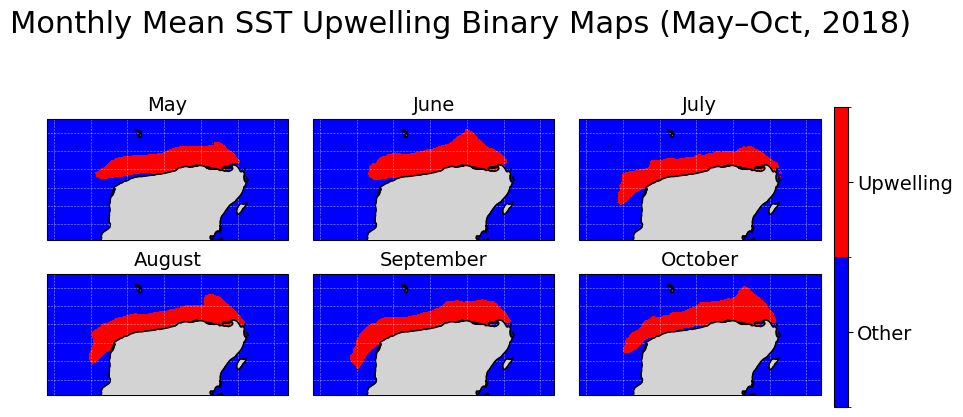

In [50]:
# 2. Extract May-October data and compute Monthly Maps
df_2018 = df.loc['2018'].copy()
target_months = range(5, 11)  # May to October
month_names_full = ['May', 'June', 'July', 'August', 'September', 'October']

monthly_binary = {}

for m in target_months:
    month_rows = df_2018[df_2018.index.month == m]
    month_grids = []
    for _, row in month_rows.iterrows():
        grid = row.get('sst')
        if grid is not None and not (isinstance(grid, float) and np.isnan(grid)):
            month_grids.append(np.array(grid, dtype=float))
            
    if month_grids:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', category=RuntimeWarning)
            mean_month_sst = np.nanmean(np.stack(month_grids), axis=0)
            
        spatial_mean = np.nanmean(mean_month_sst)
        spatial_std = np.nanstd(mean_month_sst)
        threshold = spatial_mean - spatial_std
        
        binary_grid = np.zeros_like(mean_month_sst)
        binary_grid[mean_month_sst <= threshold] = 1
        binary_grid[np.isnan(mean_month_sst)] = np.nan
        monthly_binary[m] = binary_grid
    else:
        monthly_binary[m] = None

# Extract coordinates from metadata
lon_centers = np.array(data['metadata']['lon_centers'])
lat_centers = np.array(data['metadata']['lat_centers'])
if lon_centers.ndim == 1 and lat_centers.ndim == 1:
    lon_grid_2d, lat_grid_2d = np.meshgrid(lon_centers, lat_centers)
else:
    lon_grid_2d, lat_grid_2d = lon_centers, lat_centers

# Region extent
lat_min, lon_min = 19.57871, -92.20216
lat_max, lon_max = 22.86906, -85.61256

fig, axes = plt.subplots(2, 3, figsize=(9, 5), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

cmap = mcolors.ListedColormap(['blue', 'red'])
cmap.set_bad('lightgray') # Color for NaNs (land/missing)
bounds = [-0.5, 0.5, 1.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

mesh_for_cbar = None

for idx, month_num in enumerate(target_months):
    ax = axes[idx]
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    # Add map features
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, zorder=4)
    ax.gridlines(draw_labels=False, linewidth=0.45, color='white', alpha=0.55, linestyle='--', zorder=2)
    
    data_grid = monthly_binary.get(month_num)
    
    if data_grid is None:
        ax.set_title(f"{month_names_full[idx]}\nNo Data", fontsize=14)
        continue
        
    mesh = ax.pcolormesh(
        lon_grid_2d, lat_grid_2d, data_grid,
        cmap=cmap, transform=ccrs.PlateCarree(),
        norm=norm, shading='auto', zorder=1
    )
    
    if mesh_for_cbar is None:
        mesh_for_cbar = mesh
        
    ax.set_title(f"{month_names_full[idx]}", fontsize=14)

# Shared Colorbar
fig.subplots_adjust(left=0.04, right=0.90, bottom=0.05, top=0.90, wspace=0.1, hspace=-0.425)
if mesh_for_cbar is not None:
    cax = fig.add_axes([0.915, 0.10 + 0.075, 0.015, 0.72 - 0.12])  # [left, bottom, width, height]
    cbar = fig.colorbar(mesh_for_cbar, cax=cax, ticks=[0, 1])
    cbar.ax.set_yticklabels(['Other', 'Upwelling'], fontsize=14)

fig.suptitle('Monthly Mean SST Upwelling Binary Maps (May–Oct, 2018)', fontsize=22, y=0.97)
plt.show()

In [3]:
# 3. Extract CDOM data based on Monthly Binary Upwelling Masks
all_month_labels = []
all_month_is_upwelling = []
all_month_s275 = []
all_month_s300 = []
all_month_a412 = []

def _is_missing_grid_local(grid_obj):
    return grid_obj is None or (isinstance(grid_obj, float) and np.isnan(grid_obj))

print("Extracting daily CDOM pixels partitioned by Monthly Mean Upwelling masks...")

for m in target_months:
    bin_grid = monthly_binary.get(m)
    if bin_grid is None or isinstance(bin_grid, float):
        continue
        
    bin_flat = bin_grid.flatten()
    month_rows = df_2018[df_2018.index.month == m]
    
    for _, row in month_rows.iterrows():
        s275 = row.get('cdom_slope_275_295')
        s300 = row.get('cdom_slope_300_600')
        a412 = row.get('cdom_412', row.get('cdom'))
        
        if any(_is_missing_grid_local(g) for g in [s275, s300, a412]):
            continue
            
        s275_flat = np.array(s275, dtype=float).flatten()
        s300_flat = np.array(s300, dtype=float).flatten()
        a412_flat = np.array(a412, dtype=float).flatten()
        
        # Only keep valid pixels where all variables are finite
        valid_mask = (
            ~np.isnan(bin_flat) & 
            ~np.isnan(s275_flat) & 
            ~np.isnan(s300_flat) & 
            ~np.isnan(a412_flat) &
            (a412_flat > 0)
        )
        
        if not np.any(valid_mask):
            continue
            
        up_flags = bin_flat[valid_mask] == 1
        
        all_month_labels.extend([m] * int(np.sum(valid_mask)))
        all_month_is_upwelling.extend(up_flags)
        all_month_s275.extend(s275_flat[valid_mask])
        all_month_s300.extend(s300_flat[valid_mask])
        all_month_a412.extend(a412_flat[valid_mask])

all_month_labels = np.array(all_month_labels, dtype=int)
all_month_is_upwelling = np.array(all_month_is_upwelling, dtype=bool)
all_month_s275 = np.array(all_month_s275)
all_month_s300 = np.array(all_month_s300)
all_month_a412 = np.array(all_month_a412)

upwelling_mask = all_month_is_upwelling == True
non_upwelling_mask = all_month_is_upwelling == False

Extracting daily CDOM pixels partitioned by Monthly Mean Upwelling masks...


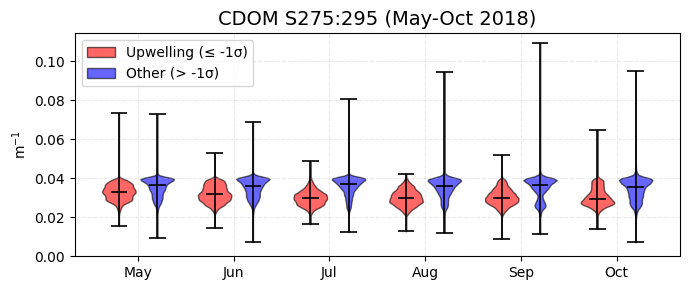

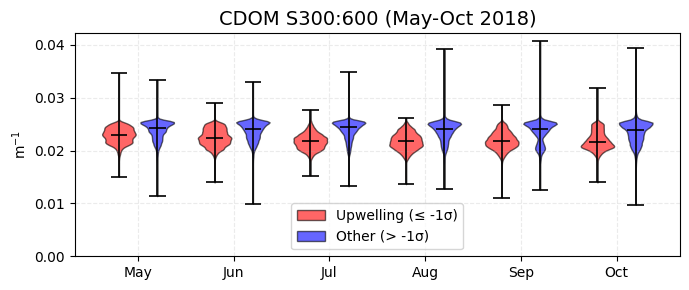

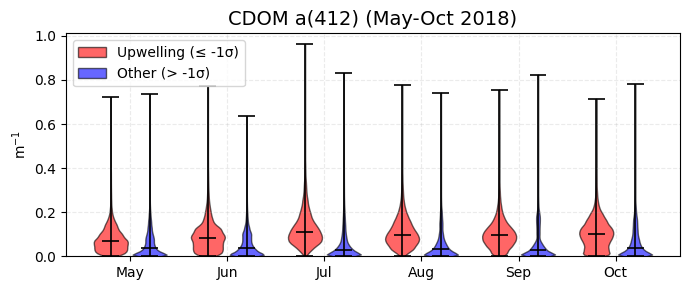

Generated 3 violin plots for May-Oct Upwelling vs Non-Upwelling CDOM comparisons.


In [42]:
# 4. Create CDOM Upwelling vs Non-Upwelling Violin Plots
def plot_monthly_upwelling_vs_nonupwelling_violin(values, var_title, y_unit):
    fig, ax = plt.subplots(figsize=(7, 3))

    up_data = []
    non_data = []
    up_positions = []
    non_positions = []
    tick_positions = []

    for idx, month in enumerate(target_months):
        month_mask = all_month_labels == month
        up_vals = values[month_mask & upwelling_mask]
        non_vals = values[month_mask & non_upwelling_mask]
        
        # Remove NaNs if any
        up_vals = up_vals[~np.isnan(up_vals)]
        non_vals = non_vals[~np.isnan(non_vals)]

        center = idx + 1
        tick_positions.append(center)

        if up_vals.size > 0:
            up_data.append(up_vals)
            up_positions.append(center - 0.2)
            
        if non_vals.size > 0:
            non_data.append(non_vals)
            non_positions.append(center + 0.2)
            
    if up_data:
        vp_up = ax.violinplot(
            up_data,
            positions=up_positions,
            widths=0.35,
            showmeans=False,
            showmedians=True,
            showextrema=True
        )
        for pc in vp_up['bodies']:
            pc.set_facecolor('red')
            pc.set_edgecolor('black')
            pc.set_alpha(0.60)
        for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
            vp_up[partname].set_edgecolor('black')
            vp_up[partname].set_linewidth(1.2)

    if non_data:
        vp_non = ax.violinplot(
            non_data,
            positions=non_positions,
            widths=0.35,
            showmeans=False,
            showmedians=True,
            showextrema=True
        )
        for pc in vp_non['bodies']:
            pc.set_facecolor('blue')
            pc.set_edgecolor('black')
            pc.set_alpha(0.60)

        for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
            vp_non[partname].set_edgecolor('black')
            vp_non[partname].set_linewidth(1.2)

    ax.set_xticks(tick_positions)
    month_names_short = ['May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct']
    ax.set_xticklabels(month_names_short)
    ax.set_ylabel(y_unit)
    ax.set_title(f'{var_title} (May-Oct 2018)',
                 fontsize=14)
    ax.grid(True, alpha=0.25, linestyle='--')
    
    # Make graph start at 0
    ax.set_ylim(bottom=0)

    legend_handles = [
        Patch(facecolor='red', edgecolor='black', alpha=0.60, label='Upwelling (≤ -1σ)'),
        Patch(facecolor='blue', edgecolor='black', alpha=0.60, label='Other (> -1σ)'),
    ]
    ax.legend(handles=legend_handles, loc='best')

    plt.tight_layout()
    plt.show()

if all_month_labels.size > 0:
    plot_monthly_upwelling_vs_nonupwelling_violin(all_month_s275, 'CDOM S275:295', 'm$^{-1}$')
    plot_monthly_upwelling_vs_nonupwelling_violin(all_month_s300, 'CDOM S300:600', 'm$^{-1}$')
    plot_monthly_upwelling_vs_nonupwelling_violin(all_month_a412, 'CDOM a(412)', 'm$^{-1}$')
    print('Generated 3 violin plots for May-Oct Upwelling vs Non-Upwelling CDOM comparisons.')
else:
    print("No valid CDOM data found to plot.")